# 鸢尾花(iris)案例

## 加载数据集

In [1]:
from sklearn.datasets import load_iris

# 1. 加载数据集
iris = load_iris()

## 翻译特征和标签

In [2]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [3]:
feature_names_cn = ['花萼长度(cm)', '花萼宽度(cm)', '花瓣长度(cm)', '花瓣宽度(cm)']

In [4]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [5]:
target_names_cn = ['山鸢尾', '变色鸢尾', '维吉尼亚鸢尾']

## 转换为DataFrame

In [6]:
import pandas as pd
df = pd.DataFrame(iris.data, columns = feature_names_cn)
df['最终分类结果'] = [target_names_cn[i] for i in iris.target]
print("========== 1. 数据集前5行预览 ==========")
print(df.head())

print("\n========== 2. 数据集包含的分类及数量 ==========")
print(df['最终分类结果'].value_counts())

========== 1. 数据集前5行预览 ==========
   花萼长度(cm)  花萼宽度(cm)  花瓣长度(cm)  花瓣宽度(cm) 最终分类结果
0       5.1       3.5       1.4       0.2    山鸢尾
1       4.9       3.0       1.4       0.2    山鸢尾
2       4.7       3.2       1.3       0.2    山鸢尾
3       4.6       3.1       1.5       0.2    山鸢尾
4       5.0       3.6       1.4       0.2    山鸢尾

========== 2. 数据集包含的分类及数量 ==========
最终分类结果
山鸢尾       50
变色鸢尾      50
维吉尼亚鸢尾    50
Name: count, dtype: int64


In [ ]:
import pandas as pd
from sklearn.datasets import load_iris

# 1. 加载数据集
iris = load_iris()

# 2. 为了方便阅读，我们将英文特征名和类别名翻译成中文
feature_names_cn = ['花萼长度(cm)', '花萼宽度(cm)', '花瓣长度(cm)', '花瓣宽度(cm)']
target_names_cn = ['山鸢尾', '变色鸢尾', '维吉尼亚鸢尾']

# 3. 转换成表格(DataFrame)形式展示
df = pd.DataFrame(iris.data, columns=feature_names_cn)
df['最终分类结果'] = [target_names_cn[i] for i in iris.target]

print("========== 1. 数据集前5行预览 ==========")
print(df.head())

print("\n========== 2. 数据集包含的分类及数量 ==========")
print(df['最终分类结果'].value_counts())

## 基尼建树

In [ ]:
### 划分数据集

In [7]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import train_test_split
# ================= 1. 划分数据 =================
X = iris.data      # 4个特征
y = iris.target    # 答案标签
# 留出30%的数据作为测试集，70%用来训练
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


### 建立并训练模型

In [8]:
from sklearn.tree import DecisionTreeClassifier
# ================= 2. 构建与训练模型 =================
# criterion='gini' : 使用基尼系数
# max_depth=3      : 树最多往下长3层（停止条件）
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)

# 开始建树（算基尼系数 -> 选特征 -> 分裂 -> 递归）
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### 预测成绩

In [9]:
from sklearn.metrics import accuracy_score
# ================= 3. 预测成绩 =================
y_pred = clf.predict(X_test)
print(f"决策树模型的预测准确率为: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

决策树模型的预测准确率为: 100.00%



### 绘图

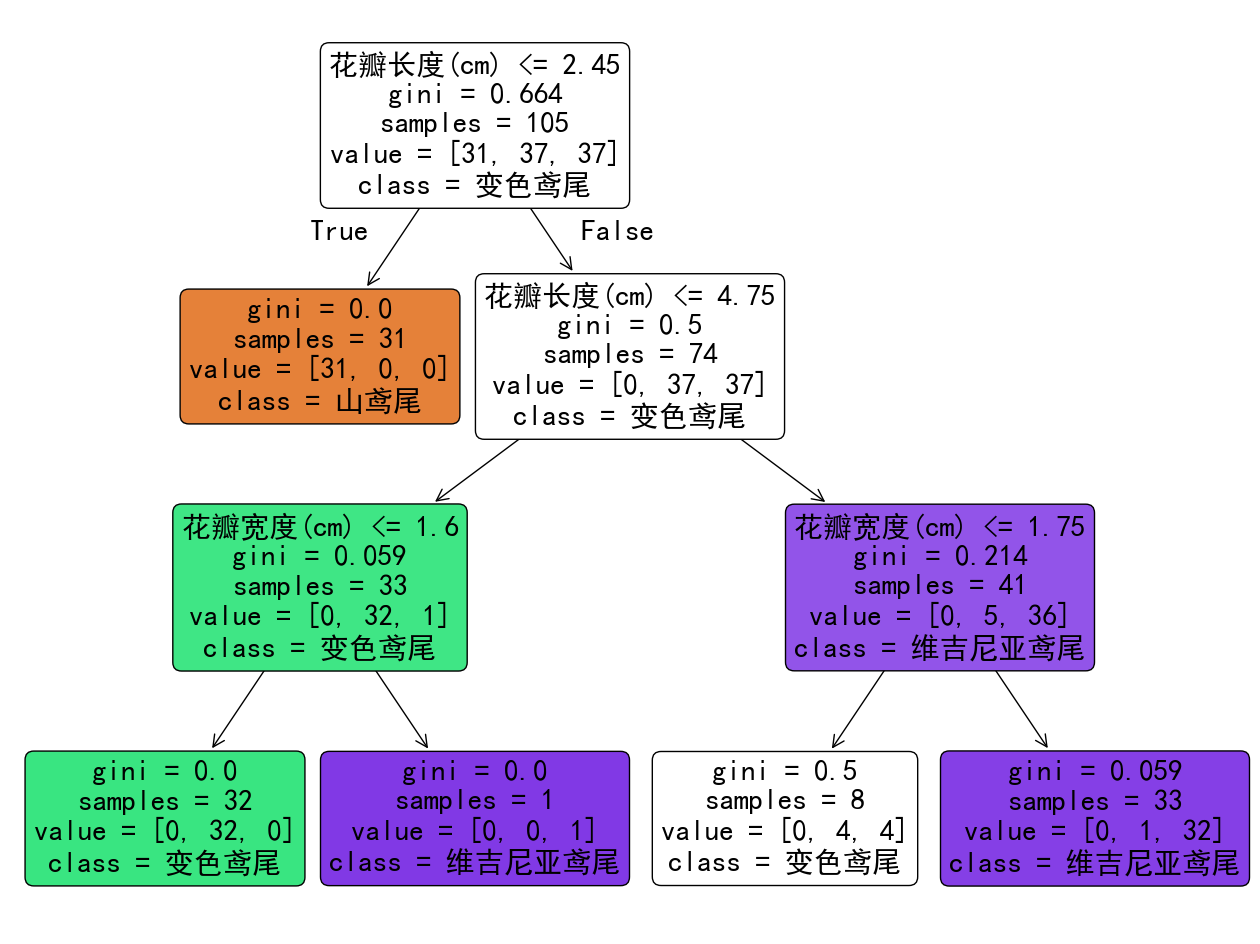

In [10]:
from sklearn import tree

# ================= 4. 画出这棵树 =================
plt.figure(figsize=(16, 12))
tree.plot_tree(clf, 
               feature_names=feature_names_cn, 
               class_names=target_names_cn,
               filled=True, # 涂色：基尼系数越小，颜色越深
               rounded=True)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
import matplotlib.pyplot as plt

# --- 中文支持 ---
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'Songti SC']
plt.rcParams['axes.unicode_minus'] = False 

# ================= 1. 划分数据 =================
X = iris.data      # 4个特征
y = iris.target    # 答案标签
# 留出30%的数据作为测试集，70%用来训练
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ================= 2. 构建与训练模型 =================
# criterion='gini' : 使用基尼系数
# max_depth=3      : 树最多往下长3层（停止条件）
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)

# 开始建树（算基尼系数 -> 选特征 -> 分裂 -> 递归）
clf.fit(X_train, y_train)

# ================= 3. 预测成绩 =================
y_pred = clf.predict(X_test)
print(f"决策树模型的预测准确率为: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

# ================= 4. 画出这棵树 =================
plt.figure(figsize=(16, 12))
tree.plot_tree(clf, 
               feature_names=feature_names_cn, 
               class_names=target_names_cn,
               filled=True, # 涂色：基尼系数越小，颜色越深
               rounded=True)
plt.show()